# Genetic Algorithm Inverse Optimization System
## Parameter Inversion for MOF Synthesis Model
Using pyGAD library for genetic algorithm optimization to find optimal reaction conditions for target particle size

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from typing import Dict, Tuple, List
import pygad

warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12

print('Libraries loaded successfully')

Libraries loaded successfully


In [96]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
# Define features and constraints
class MOFOptimizationConfig:
    """Configuration for MOF synthesis parameter optimization"""
    
    # Numeric feature ranges (min, max)
    NUMERIC_RANGES = {
        'temperature_C': (24, 30),
        'time_min': (9, 35),
        'hmim_mM': (0.0002466, 0.11133),
        'zn_source_mM': (4.084445490301542e-05, 0.0178),
        'ratio': (0.009, 0.015)
    }
    
    # Ordinal feature (stirring)
    STIRRING_ORDER = ['No', 'Initial', 'Yes', 'Yes dropwise']
    
    # Categorical feature options (one-hot encoded in model)
    CATEGORICAL_OPTIONS = {
        'counterion': ['NO3-', 'CH3COO-', 'SO42-', 'ClO4-'],
        'solvent_name': ['Water','Methanol','Ethanol']
    }
    
    NUMERIC_FEATURES = list(NUMERIC_RANGES.keys())  # 5 features
    ORDINAL_FEATURES = ['stirring']  # 1 feature (ordinal encoded)
    CATEGORICAL_FEATURES = list(CATEGORICAL_OPTIONS.keys())  # 2 features (one-hot encoded)
    
    # Genetic Algorithm parameters
    GA_PARAMS = {
        'num_generations': 100,
        'num_parents_mating': 10,
        'sol_per_pop': 50,
        'mutation_percent_genes': 20,
        'crossover_type': 'two_points',
        'mutation_type': 'random',
        'parent_selection_type': 'tournament',
        'tournament_participants_count': 2,
        #'keep_elitism': 2
    }

print('Configuration defined')
print(f'Numeric features (5): {MOFOptimizationConfig.NUMERIC_FEATURES}')
print(f'Ordinal features (1): {MOFOptimizationConfig.ORDINAL_FEATURES}')
print(f'Categorical features (2, one-hot in model): {MOFOptimizationConfig.CATEGORICAL_FEATURES}')

class GAInverseOptimizer:
    """MOF synthesis parameter inverse optimization using genetic algorithm"""
    
    def __init__(self, model, target_size: float):
        """
        Initialize the optimizer
        
        Args:
            model: Trained predictive model
            target_size: Target particle size (nm)
        """
        self.model = model
        self.target_size = target_size
        self.config = MOFOptimizationConfig
        
        
        # Initialize encoders to match model training
        self.ordinal_encoder = OrdinalEncoder(
            categories=[self.config.STIRRING_ORDER],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        )
        self.onehot_encoder = OneHotEncoder(
            categories=[self.config.CATEGORICAL_OPTIONS['counterion'],
                       self.config.CATEGORICAL_OPTIONS['solvent_name']],
            sparse_output=False,
            handle_unknown='ignore'
        )
        
        # Number of genes needed: 5 numeric + 1 ordinal + 2 categorical
        self.num_numeric = len(self.config.NUMERIC_FEATURES)
        self.num_ordinal = len(self.config.ORDINAL_FEATURES)
        self.num_categorical = len(self.config.CATEGORICAL_FEATURES)
        self.num_genes = self.num_numeric + self.num_ordinal + self.num_categorical
        
        # Record optimization history
        self.fitness_history = []
        self.best_solution = None
        self.best_fitness = float('inf')
        self.predictions_history = []
        self.all_history = []
    
    def get_gene_space(self):
        """
        Create gene_space list for pyGAD to enforce constraints
        Format: list of (min, max) tuples for each gene
        """
        gene_space = []
        
        # 5 numeric features: [0, 100] for normalization
        for _ in range(self.num_numeric):
            gene_space.append({'low': 0, 'high': 100})
        
        # 1 ordinal feature (stirring): [0, len(STIRRING_ORDER)-1]
        gene_space.append([i for i in range(len(self.config.STIRRING_ORDER))])
        
        # Categorical features
        # counterion: [0, len(counterion)-1]
        gene_space.append([i for i in range(len(self.config.CATEGORICAL_OPTIONS['counterion']))])
        
        
        gene_space.append([i for i in range(len(self.config.CATEGORICAL_OPTIONS['solvent_name']))])
        
        return gene_space
        
    def decode_solution(self, solution: np.ndarray) -> Dict:
        """
        Decode genes into parameter dictionary
        """
        params = {}
        
        # Decode numeric features
        for i, feature in enumerate(self.config.NUMERIC_FEATURES):
            min_val, max_val = self.config.NUMERIC_RANGES[feature]
            normalized = (solution[i] % 100) / 100.0
            params[feature] = min_val + normalized * (max_val - min_val)
        
        # Decode ordinal feature (stirring)
        idx = int(solution[self.num_numeric]) % len(self.config.STIRRING_ORDER)
        params['stirring'] = self.config.STIRRING_ORDER[idx]
        
        # Decode categorical features
        for i, feature in enumerate(self.config.CATEGORICAL_FEATURES):
            options = self.config.CATEGORICAL_OPTIONS[feature]
            idx = int(solution[self.num_numeric + self.num_ordinal + i]) % len(options)
            params[feature] = options[idx]
        
        # Override solvent if masked
        # if self.solvent_mask is not None:
        #     params['solvent_name'] = self.solvent_mask

        
        params['ratio'] = params['zn_source_mM'] / params['hmim_mM']
        
        return params
    
    def fitness_function(self, ga_instance, solution, solution_idx):
        """
        Fitness function: minimize difference between predicted and target values
        """
        params = self.decode_solution(solution)
        
        X = pd.DataFrame([params])
        
        try:
            # Prediction
            #print(X)
            predicted_size = self.model.predict(X)[0]
            
            # Calculate error
            error = abs(predicted_size - self.target_size)
            
            # Fitness = -error
            fitness = -error
        except Exception as e:
            print(f"Error in fitness calculation: {e}")
            fitness = -1000  # Large penalty
        
        # Record history
        self.predictions_history.append({
            'predicted_size': predicted_size if 'predicted_size' in locals() else None,
            'error': error if 'error' in locals() else 1000
        })
        
        return fitness
    
    def callback_generation(self, ga_instance):
        """Callback function for each generation"""
        best_fitness = ga_instance.best_solutions_fitness[-1]
        self.fitness_history.append(best_fitness)
        gen_num = ga_instance.generations_completed
        current_pop = ga_instance.population.copy()
        current_fitness = ga_instance.last_generation_fitness.copy()
        
        for i in range(len(current_pop)):
            params = self.decode_solution(current_pop[i].tolist())
            X = pd.DataFrame([params])
            self.all_history.append({
                'generation': gen_num,
                'individual_idx': i,
                #'parameters': current_pop[i].tolist(), 
                
                'fitness': current_fitness[i],
                'size': self.model.predict(X)[0]
        }| params
        
        )
            
        if best_fitness > self.best_fitness:
            self.best_fitness = best_fitness
            self.best_solution = ga_instance.best_solution.copy()
        
        if (ga_instance.generations_completed + 1) % 20 == 0:
            print(f"Generation {ga_instance.generations_completed + 1}/{self.config.GA_PARAMS['num_generations']} completed")
            print(f"  Best fitness: {best_fitness:.4f}")
            if best_fitness < 0:
                print(f"  Predicted error: {abs(best_fitness):.2f} nm")
    
    def optimize(self, verbose=True):
        """Execute genetic algorithm optimization"""
        print(f'Starting genetic algorithm optimization...')
        print(f'Target particle size: {self.target_size} nm')
        print(f'Population size: {self.config.GA_PARAMS["sol_per_pop"]}')
        print(f'Number of generations: {self.config.GA_PARAMS["num_generations"]}')
        print(f'Total genes: {self.num_genes}')
        print()
        
        # Get gene space with constraints
        gene_space = self.get_gene_space()
        
        ga = pygad.GA(
            num_generations=self.config.GA_PARAMS['num_generations'],
            num_parents_mating=self.config.GA_PARAMS['num_parents_mating'],
            sol_per_pop=self.config.GA_PARAMS['sol_per_pop'],
            num_genes=self.num_genes,
            fitness_func=self.fitness_function,
            on_generation=self.callback_generation,
            mutation_percent_genes=self.config.GA_PARAMS['mutation_percent_genes'],
            crossover_type=self.config.GA_PARAMS['crossover_type'],
            mutation_type=self.config.GA_PARAMS['mutation_type'],
            parent_selection_type=self.config.GA_PARAMS['parent_selection_type'],
            gene_space=gene_space,
            gene_type=float,
            random_seed=42,
            save_best_solutions=True,
            suppress_warnings=True
        )
        
        ga.run()
        
        # Get optimal solution
        solution, fitness, _ = ga.best_solution()
        self.best_solution = solution
        self.best_fitness = fitness
        
        print(f'\nOptimization completed!')
        print(f'Best fitness: {fitness:.4f}')
        
        return self.decode_solution(solution), ga
    
    def get_best_params(self) -> Dict:
        """Get optimal parameters"""
        return self.decode_solution(self.best_solution)
    
    def predict_with_best(self) -> float:
        """Predict particle size using optimal parameters"""
        params = self.get_best_params()
        X = pd.DataFrame([params])
        
        return self.model.predict(X)[0]

print('GAInverseOptimizer class defined successfully')

Configuration defined
Numeric features (5): ['temperature_C', 'time_min', 'hmim_mM', 'zn_source_mM', 'ratio']
Ordinal features (1): ['stirring']
Categorical features (2, one-hot in model): ['counterion', 'solvent_name']
GAInverseOptimizer class defined successfully


In [18]:
def save_optimization_results(optimizers_dict, filepath='ga_optimization_results.csv'):
    """
    Save optimization results to CSV file
    
    Args:
        optimizers_dict: {target_size: optimizer} dictionary
        filepath: Output file path
    """
    results = []
    
    for target_size in sorted(optimizers_dict.keys()):
        optimizer = optimizers_dict[target_size]
        best_params = optimizer.get_best_params()
        predicted_size = optimizer.predict_with_best()
        error = abs(predicted_size - target_size)
        
        row = {
            'target_size_nm': target_size,
            'predicted_size_nm': predicted_size,
            'error_nm': error,
            'error_percent': (error / target_size) * 100,
            'best_fitness': optimizer.best_fitness,
        }
        
        # Add optimal parameters
        for param, value in best_params.items():
            row[f'opt_{param}'] = value
        
        results.append(row)
    
    results_df = pd.DataFrame(results)
    results_df.to_csv(filepath, index=False)
    
    print(f'Results saved to: {filepath}')
    return results_df

print('save_optimization_results function defined successfully')

save_optimization_results function defined successfully


In [19]:
from pathlib import Path

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

class GAOptimizationVisualizer:
    def __init__(self, optimizer, output_dir='ga_visualizations'):
        self.optimizer = optimizer
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.plot_data = {}

    def _save_figure(self, fig, name):
        for ext in ['png', 'pdf', 'svg']:
            filepath = self.output_dir / f"{name}.{ext}"
            fig.savefig(filepath, format=ext, bbox_inches='tight', transparent=False, dpi=300)
        plt.close(fig)

    def plot_fitness_evolution(self):
        generations = np.arange(len(self.optimizer.fitness_history))
        fitness = np.array(self.optimizer.fitness_history)

        fig, ax = plt.subplots(figsize=(9, 6))
        ax.plot(generations, fitness, color='tab:blue', linewidth=1.8, marker='o', markersize=4)
        ax.set_xlabel('Generation')
        ax.set_ylabel('Fitness (negative error)')
        ax.grid(alpha=0.3)

        self.plot_data['fitness_evolution'] = pd.DataFrame({'generation': generations, 'fitness': fitness})
        self._save_figure(fig, 'ga_fitness_evolution')

        return fig

    def plot_error_convergence(self):
        generations = np.arange(len(self.optimizer.fitness_history))
        error = -np.array(self.optimizer.fitness_history)

        fig, ax = plt.subplots(figsize=(9, 6))
        ax.plot(generations, error, color='tab:green', linewidth=1.8, marker='o', markersize=4)
        ax.set_xlabel('Generation')
        ax.set_ylabel('Prediction Error (nm)')
        ax.grid(alpha=0.3)

        self.plot_data['error_convergence'] = pd.DataFrame({'generation': generations, 'error_nm': error})
        self._save_figure(fig, 'ga_error_convergence')

        return fig

    def save_plot_data(self):
        for name, df in self.plot_data.items():
            csv_path = self.output_dir / f"{name}.csv"
            df.to_csv(csv_path, index=False)
            json_path = self.output_dir / f"{name}.json"
            df.to_json(json_path, orient='records', lines=False)


## Step 2: Load Trained Model
Now we load the trained model that predicts particle size from synthesis parameters.

In [20]:
# Load the trained model
import os
model_path = 'ml_models/final_prod_model.pkl'
model_filename = model_path

if os.path.exists(model_filename):
    model = joblib.load(model_filename)
    print(f"✅ Model loaded successfully: {model_filename}")
    print(f"Model type: {type(model).__name__}")
else:
    print(f"❌ Model file not found: {model_filename}")
    print(f"Looking for alternative models...")
    pkl_files = [f for f in os.listdir('.') if f.endswith('.pkl')]
    if pkl_files:
        print(f"Available .pkl files: {pkl_files}")
    else:
        print("No .pkl files found in current directory")

✅ Model loaded successfully: ml_models/final_prod_model.pkl
Model type: Pipeline


## Step 3: Run GA Optimization for Target Particle Size
Optimize synthesis parameters to achieve a specific target particle size.


In [97]:
import warnings
warnings.filterwarnings('ignore')

# ⭐ SET YOUR TARGET PARTICLE SIZE HERE (in nanometers)
target_size = 100  # Change this value to your desired target size

# ⭐ GENE MASKING: Set solvent constraint
solvent_mask = 'Water'  # Options: 'Water', 'Methanol', or None for free optimization

print(f"\n{'='*70}")
print(f"  Genetic Algorithm Optimization")
print(f"  Target Particle Size: {target_size} nm")
print(f"{'='*70}\n")

# Create optimizer instance with gene masking
optimizer = GAInverseOptimizer(model, target_size)

# Run optimization
best_params, ga_instance = optimizer.optimize()

print(f"\n{'='*70}")
print(f"  OPTIMIZATION COMPLETE")
print(f"{'='*70}\n")

# Display results
print("📊 BEST SYNTHESIS PARAMETERS FOUND:")
print("-" * 70)
best_params_dict = optimizer.get_best_params()
for param_name, param_value in best_params_dict.items():
    if param_name in MOFOptimizationConfig.NUMERIC_RANGES:
        print(f"  {param_name:20s}: {param_value:12.6f}")
    else:
        if param_name == 'solvent_name' and solvent_mask is not None:
            print(f"  {param_name:20s}: {param_value} ")
        else:
            print(f"  {param_name:20s}: {param_value}")

# Predict with best parameters
predicted_size = optimizer.predict_with_best()
print(f"\n   Predicted particle size: {predicted_size:.2f} nm")
print(f"   Target particle size:   {target_size:.2f} nm")
error = abs(predicted_size - target_size)
print(f"   Prediction error:        {error:.2f} nm ({error/target_size*100:.2f}%)")

# Store results for visualization
optimization_results = {
    'target_size': target_size,
    'predicted_size': predicted_size,
    'best_params': best_params_dict,
    'ga_instance': ga_instance,
    'optimizer': optimizer
}

print(f"\n{'='*70}\n")


  Genetic Algorithm Optimization
  Target Particle Size: 100 nm

Starting genetic algorithm optimization...
Target particle size: 100 nm
Population size: 50
Number of generations: 100
Total genes: 8

Generation 20/100 completed
  Best fitness: -0.0134
  Predicted error: 0.01 nm
Generation 40/100 completed
  Best fitness: -0.0134
  Predicted error: 0.01 nm
Generation 60/100 completed
  Best fitness: -0.0134
  Predicted error: 0.01 nm
Generation 80/100 completed
  Best fitness: -0.0128
  Predicted error: 0.01 nm
Generation 100/100 completed
  Best fitness: -0.0128
  Predicted error: 0.01 nm

Optimization completed!
Best fitness: -0.0128

  OPTIMIZATION COMPLETE

📊 BEST SYNTHESIS PARAMETERS FOUND:
----------------------------------------------------------------------
  temperature_C       :    24.064021
  time_min            :    20.064648
  hmim_mM             :     0.079472
  zn_source_mM        :     0.001694
  ratio               :     0.021320
  stirring            : Yes
  counterio

In [98]:
df = pd.DataFrame(optimizer.all_history)

df.to_csv('Data/ga_inverse.csv',index=False)

In [10]:
df = pd.read_csv('Data/ga_inverse.csv')

df['ingroup_rank']=df.groupby('generation')['fitness'].transform(lambda x: x.rank(ascending=False,method='min'))
df = df.query("generation<21 and ingroup_rank < 11 ")
df

,generation,individual_idx,fitness,size,temperature_C,time_min,hmim_mM,zn_source_mM,ratio,stirring,counterion,solvent_name,ingroup_rank
0,1,0,-20.622910,120.622910,24.558617,32.327610,0.100268,0.011284,0.112540,Yes dropwise,NO3-,Water,4.0
11,1,11,-28.649332,128.649332,25.738509,13.191753,0.103521,0.003812,0.036822,Yes,NO3-,Water,9.0
13,1,13,-11.529198,111.529198,25.501457,32.298374,0.035572,0.003812,0.107159,Yes,NO3-,Water,2.0
14,1,14,-20.622910,120.622910,25.452332,26.475524,0.084850,0.009795,0.115435,Yes,NO3-,Water,4.0
24,1,24,-24.004221,124.004221,24.123507,24.904739,0.084850,0.004261,0.050219,Yes,NO3-,Water,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,20,27,-1.926844,101.926844,26.845043,26.096568,0.006343,0.001872,0.295159,Yes dropwise,NO3-,Methanol,9.0
982,20,32,-1.230933,98.769067,29.929652,14.930074,0.006343,0.001922,0.303017,Yes,NO3-,Methanol,4.0
984,20,34,-0.690933,99.309067,26.845043,21.907990,0.006343,0.001872,0.295159,Yes,NO3-,Methanol,2.0
998,20,48,-1.230933,98.769067,26.845043,13.182053,0.006343,0.001872,0.295159,Yes,NO3-,Methanol,4.0


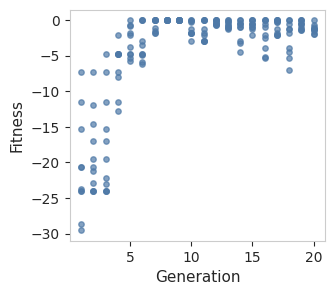

In [16]:
fig = plt.figure(figsize=(3.3,3))

ax = fig.add_subplot(1,1,1)
ax.grid(visible=False)
ax.scatter(df['generation'],df['fitness'],alpha=0.7,s=15,c='#4E79A7')
ax.set_xlabel('Generation')
ax.set_ylabel('Fitness')
ax.tick_params(axis='both',which='both',bottom=True,left=True)

## Step 4: Visualize Optimization Results
Display the optimization history and convergence

In [88]:


optimizer = optimization_results['optimizer']
visualizer = GAOptimizationVisualizer(optimizer)

visualizer.plot_fitness_evolution()
visualizer.plot_error_convergence()
visualizer.save_plot_data()

print('✅ Visualization complete with saved figures and plot data.')

✅ Visualization complete with saved figures and plot data.


## Step 6: Export Results
Save the optimization results to CSV and other formats for further analysis.

In [10]:
# Export single-target results to CSV
if 'optimization_results' in locals():
    single_results_list = []
    result = optimization_results
    params = result['best_params'].copy()
    params['target_size_nm'] = result['target_size']
    params['predicted_size_nm'] = result['predicted_size']
    params['error_nm'] = abs(result['predicted_size'] - result['target_size'])
    single_results_list.append(params)
    
    df_single = pd.DataFrame(single_results_list)
    single_csv_file = f"GA_optimization_result_{result['target_size']}nm.csv"
    df_single.to_csv(single_csv_file, index=False)
    print(f" Single-target results exported to: {single_csv_file}")

print("\n Export complete!")

✅ Single-target results exported to: GA_optimization_result_100nm.csv

✅ Export complete!
